In [1]:
# Author: Gergely Zahoranszky-Kohalmi, PhD
#
# Email: gergely.zahoranszky-kohalmi@nih.gov
#
# Organization: National Center for Advancing Translational Sciences
#

In [ ]:
# Env: rev_plot
import os
import pandas as pd
import seaborn as sns
import scipy
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

In [ ]:
FNAME_IN_SIM = '../data/output/route_diversity_stats.tsv'

FNAME_IN_EVIDENCE_TIME_LASM = '../data/output/route_finding_leaves_as_sm_timing_stats_rxsmiles.tsv'
FNAME_IN_EVIDENCE_TIME_INV = '../data/output/route_finding_with_inventory_timing_stats_rxsmiles.tsv'

FNAME_OUT_PLOT_SIM_DIST = '../data/output/plots/si_Fig_S1_sim_dist.png'

FNAME_OUT_PLOT_TIME_DIST = '../data/output/plots/si_Fig_S2_processing_time_dist.png'

os.makedirs('../data/output/plots/', exist_ok=True)

In [4]:
# Parse input

df_sim = pd.read_csv (FNAME_IN_SIM, sep = '\t')

print (df_sim.head)


df_evidence_time_lasm = pd.read_csv (FNAME_IN_EVIDENCE_TIME_LASM, sep = '\t')

print (df_evidence_time_lasm.head)


df_evidence_time_inv = pd.read_csv (FNAME_IN_EVIDENCE_TIME_INV, sep = '\t')
print (df_evidence_time_inv.head)

<bound method NDFrame.head of                      tm_inchikey  mean_similarity  std_similarity  \
0    BVKGNQRDVFGNIW-UHFFFAOYSA-N         0.125988        0.308607   
1    CUIMTAPGPJXQEK-UHFFFAOYSA-N         0.365963        0.000000   
2    DBQFEMRSLALWEZ-UHFFFAOYSA-N         0.581774        0.000000   
3    DJRUWESABPZMRB-UHFFFAOYSA-N         0.505924        0.138608   
4    DLLGXKPWXXZQFL-UHFFFAOYSA-N         0.463898        0.028849   
..                           ...              ...             ...   
159  YKAKSKHYOAHFDB-UHFFFAOYSA-N         0.696934        0.101789   
160  YTINZZFBHWSAGL-NDEPHWFRSA-N         0.779006        0.127870   
161  ZQXOMIPSVVBRGV-UHFFFAOYSA-N         0.761797        0.020127   
162  ZTXVRZLOVRFPEC-UHFFFAOYSA-N         0.643953        0.150779   
163  ZVERWTXKKWSSHH-UHFFFAOYSA-N         0.250605        0.346617   

     triangular_simmx_size     route_type  
0                        6  evidence_lasm  
1                        1  evidence_lasm  
2        

In [5]:
# Data transformations

df_evidence_time_lasm['sm_type'] = 'leaves_as_sm'
df_evidence_time_inv['sm_type'] = 'inventory'

df_evidence_time_lasm['total_time_sec'] = df_evidence_time_lasm['route_find_time_sec'] + df_evidence_time_lasm['synth_graph_assembly_time_sec']

df_evidence_time_inv['total_time_sec'] = df_evidence_time_inv['route_find_time_sec'] + df_evidence_time_inv['synth_graph_assembly_time_sec']

df_time_evidence = pd.concat ([df_evidence_time_lasm, df_evidence_time_inv])

print (df_time_evidence.head)





<bound method NDFrame.head of                              tm  route_find_time_sec  \
0   DUCJUKZQSRPECI-UHFFFAOYSA-N             0.028570   
1   UZCLUOWLQYOFSZ-UHFFFAOYSA-N             0.001142   
2   WTCXKDSZUHYCLH-UHFFFAOYSA-N             0.003861   
3   FMXLKQYOBUDPPG-UHFFFAOYSA-N             0.001594   
4   FOROUCWBDGYYOS-NSHDSACASA-N             0.004234   
..                          ...                  ...   
29  QIXXLCJOJGHZJB-UHFFFAOYSA-N             0.000558   
30  ILMBNGXIGGVYQY-UHFFFAOYSA-N             0.003715   
31  DLLGXKPWXXZQFL-UHFFFAOYSA-N             0.001477   
32  BIAAFFAHROMCHN-UHFFFAOYSA-N             0.001875   
33  NVTKJBXOBFRPLQ-UHFFFAOYSA-N             0.033021   

    synth_graph_assembly_time_sec       sm_type  total_time_sec  
0                        0.210560  leaves_as_sm        0.239130  
1                        0.010728  leaves_as_sm        0.011870  
2                        0.020449  leaves_as_sm        0.024310  
3                        0.020463

# Diversity Analysis

## Statistical Framework


- Only performing test on routes of target molecules for which both method was able to identify routes.
- Assumptions:
- No equality of variance
- No underlying normal distribution
- No independence of data
- Repeated measurements

- Applicable Test: Non-parametric Signed-Rank Wilcoxon Test

### Starting materials (building-blocks) defined as the leaf nodes in the synthesis graph



In [6]:
# Stats:



df_x = df_sim[df_sim['route_type'] == 'evidence_lasm'].copy()

nr_ev_routes_sim_lan = df_x.shape[0]




df_y = df_sim[df_sim['route_type'] == 'predicted'].copy()

nr_pred_routes_sim = df_y.shape[0]

df_common = df_x.merge(df_y, on = 'tm_inchikey', how = 'inner')

tms_common = list(set(list(df_common['tm_inchikey'])))


df_x = df_x[df_x['tm_inchikey'].isin(tms_common)].copy()


df_y = df_y[df_y['tm_inchikey'].isin(tms_common)].copy()

print (df_x.shape)
print (df_y.shape)



X = list(df_x['mean_similarity'])
Y = list(df_y['mean_similarity'])




res = wilcoxon (X, Y)



print (res)

(22, 5)
(22, 5)
WilcoxonResult(statistic=36.0, pvalue=0.0021948814392089844)


Index(['tm_inchikey', 'mean_similarity', 'std_similarity',
       'triangular_simmx_size', 'route_type'],
      dtype='object')
[*] Number of common routes (betweev evidence - leaves as sm and predicted types): 22 .
<bound method NDFrame.head of                      tm_inchikey  mean_similarity  std_similarity  \
3    DJRUWESABPZMRB-UHFFFAOYSA-N         0.505924        0.138608   
4    DLLGXKPWXXZQFL-UHFFFAOYSA-N         0.463898        0.028849   
5    DUCJUKZQSRPECI-UHFFFAOYSA-N         0.423659        0.000000   
6    FBEAEYZRUGTMAE-UHFFFAOYSA-N         0.475207        0.000000   
7    FHZZJWMSTHGNQS-UHFFFAOYSA-N         0.471405        0.000000   
8    FOROUCWBDGYYOS-NSHDSACASA-N         0.388012        0.000000   
11   GZYNUOMXGGSXMI-UHFFFAOYSA-N         0.343558        0.053131   
12   HGCVGTDJTDDWLM-UHFFFAOYSA-N         0.457493        0.000000   
15   ILMBNGXIGGVYQY-UHFFFAOYSA-N         0.000000        0.000000   
16   INTQQNKAQDJOOI-UHFFFAOYSA-N         0.528271        0.00000

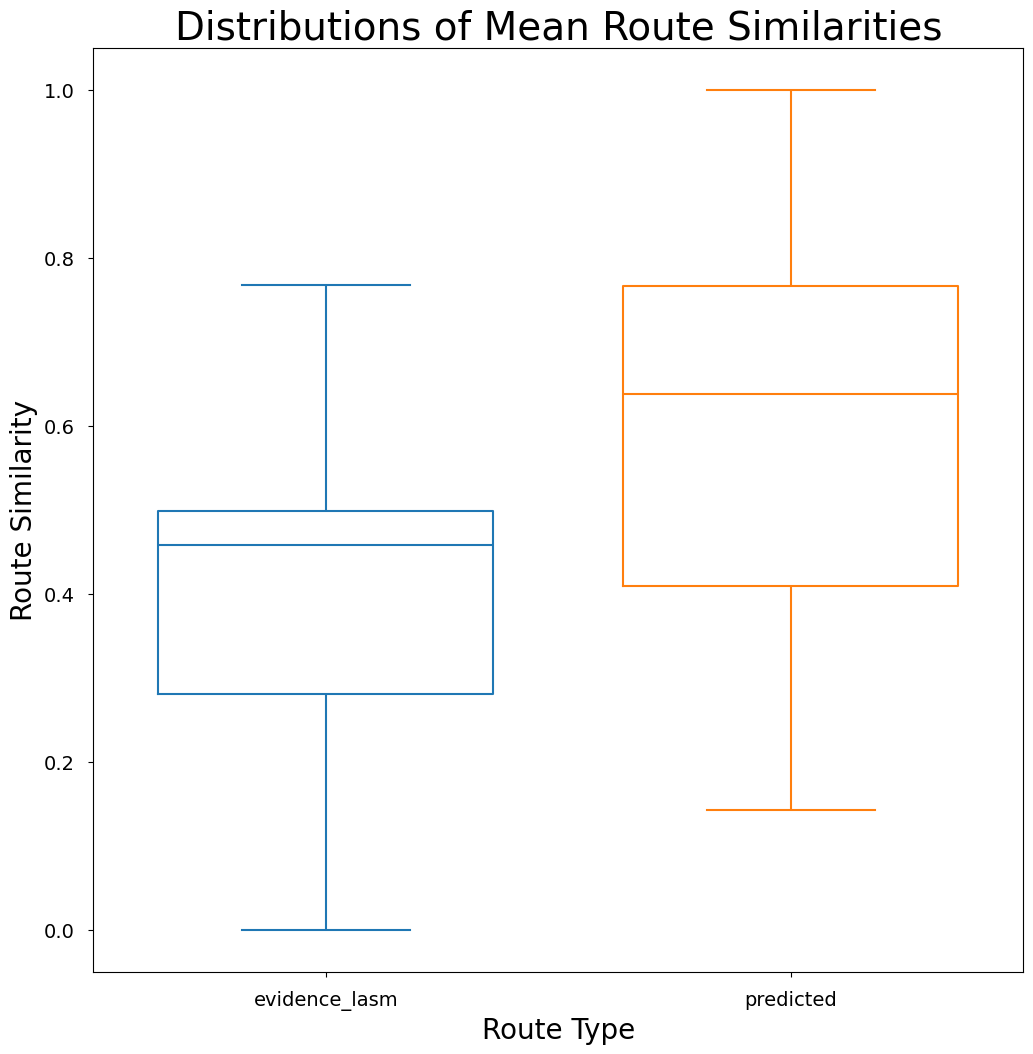

In [7]:
print (df_x.columns)

df_sim_common = df_x.merge (df_y, on = 'tm_inchikey', how = 'inner')

common_inchikeys = list(set(list(df_sim_common['tm_inchikey'])))

print (f'[*] Number of common routes (betweev evidence - leaves as sm and predicted types): {len(common_inchikeys)} .')

df_x = df_x[df_x['tm_inchikey'].isin(common_inchikeys)].copy()
df_y = df_y[df_y['tm_inchikey'].isin(common_inchikeys)].copy()

df_sim_common = pd.concat([df_x, df_y])


print (df_sim_common.head)

plt.figure(figsize=(12,12))

#plt.title('Distributions of Mean Route Similarities\nLeaves as SM = True', fontsize = 28)
plt.title('Distributions of Mean Route Similarities', fontsize = 28)



ax = sns.boxplot(data = df_sim_common, x = 'route_type', y = 'mean_similarity', hue = 'route_type', fill=False, gap = 0.1)


ax.set_xlabel("Route Type", fontsize=20)
ax.set_ylabel("Route Similarity", fontsize=20)
ax.tick_params(axis='both', labelsize=14, pad = 10)

plt.savefig(FNAME_OUT_PLOT_SIM_DIST)
plt.show()          
plt.close()


In [8]:
print(f'Number of routes in evidence-based search (leaves_as_sm = True): {nr_ev_routes_sim_lan}')

print(f'Number of predicted routes: {nr_pred_routes_sim}')

print (f'Number of common routes with evidence-based routes (leaves_as_sm = True): {df_x.shape[0]} (checking the number of matching predicted routes for verification: {df_y.shape[0]})')




Number of routes in evidence-based search (leaves_as_sm = True): 38
Number of predicted routes: 121
Number of common routes with evidence-based routes (leaves_as_sm = True): 22 (checking the number of matching predicted routes for verification: 22)


### Starting materials (building-blocks) defined by a virtual inventory

# Comparison of Processing Times of Route Identification

### Starting materials (building-blocks) defined as the leaf nodes in the synthesis graph

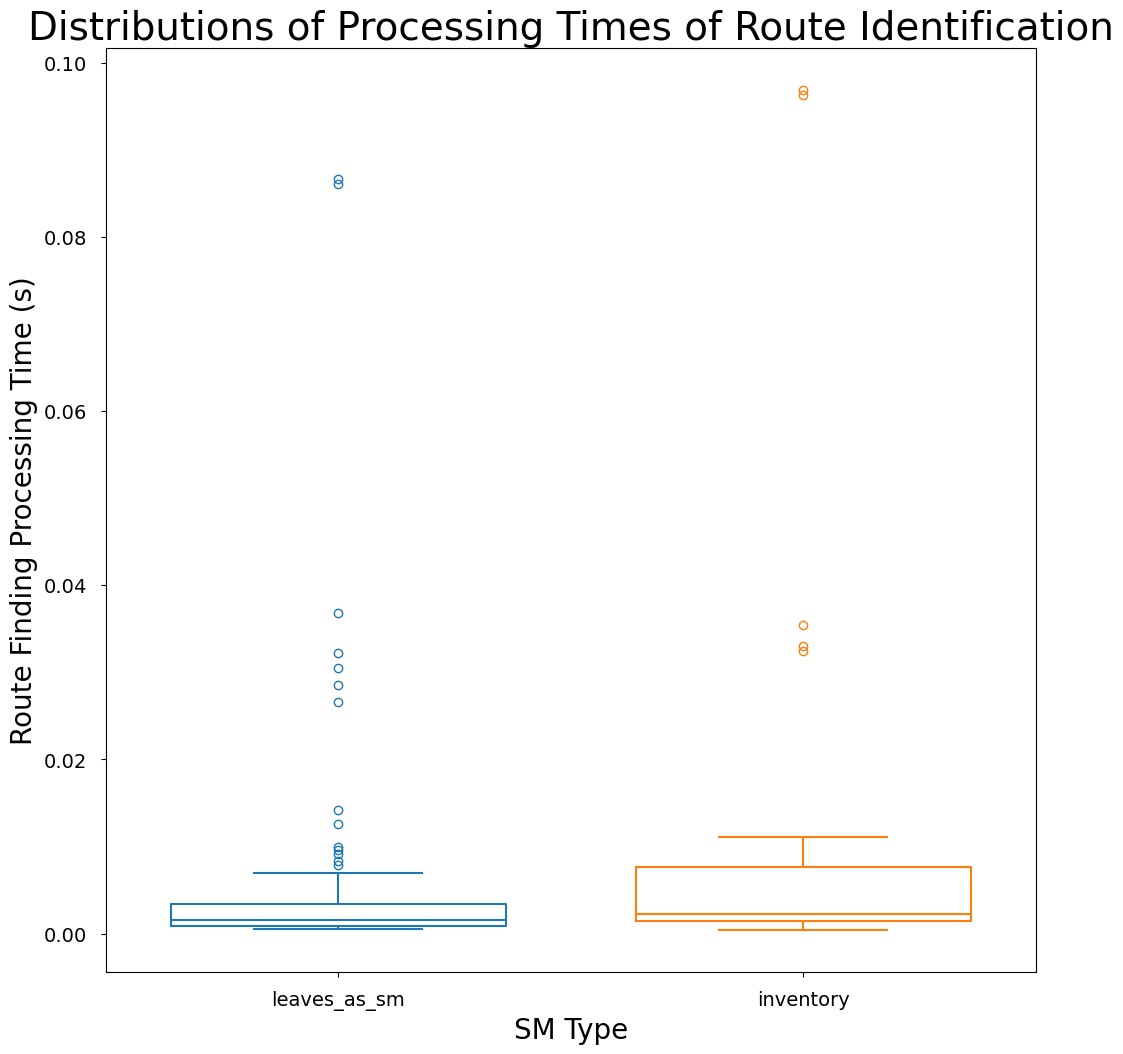

In [9]:


plt.figure(figsize=(12,12))

plt.title('Distributions of Processing Times of Route Identification', fontsize = 28)


ax = sns.boxplot(data = df_time_evidence, x = 'sm_type', y = 'route_find_time_sec', hue = 'sm_type', fill=False, gap = 0.1)


ax.set_xlabel("SM Type", fontsize=20)
ax.set_ylabel("Route Finding Processing Time (s)", fontsize=20)
ax.tick_params(axis='both', labelsize=14, pad = 10)

#plt.savefig(FNAME_OUT_PLOT_SIM_DIST_LAN)
plt.show()          
plt.close()


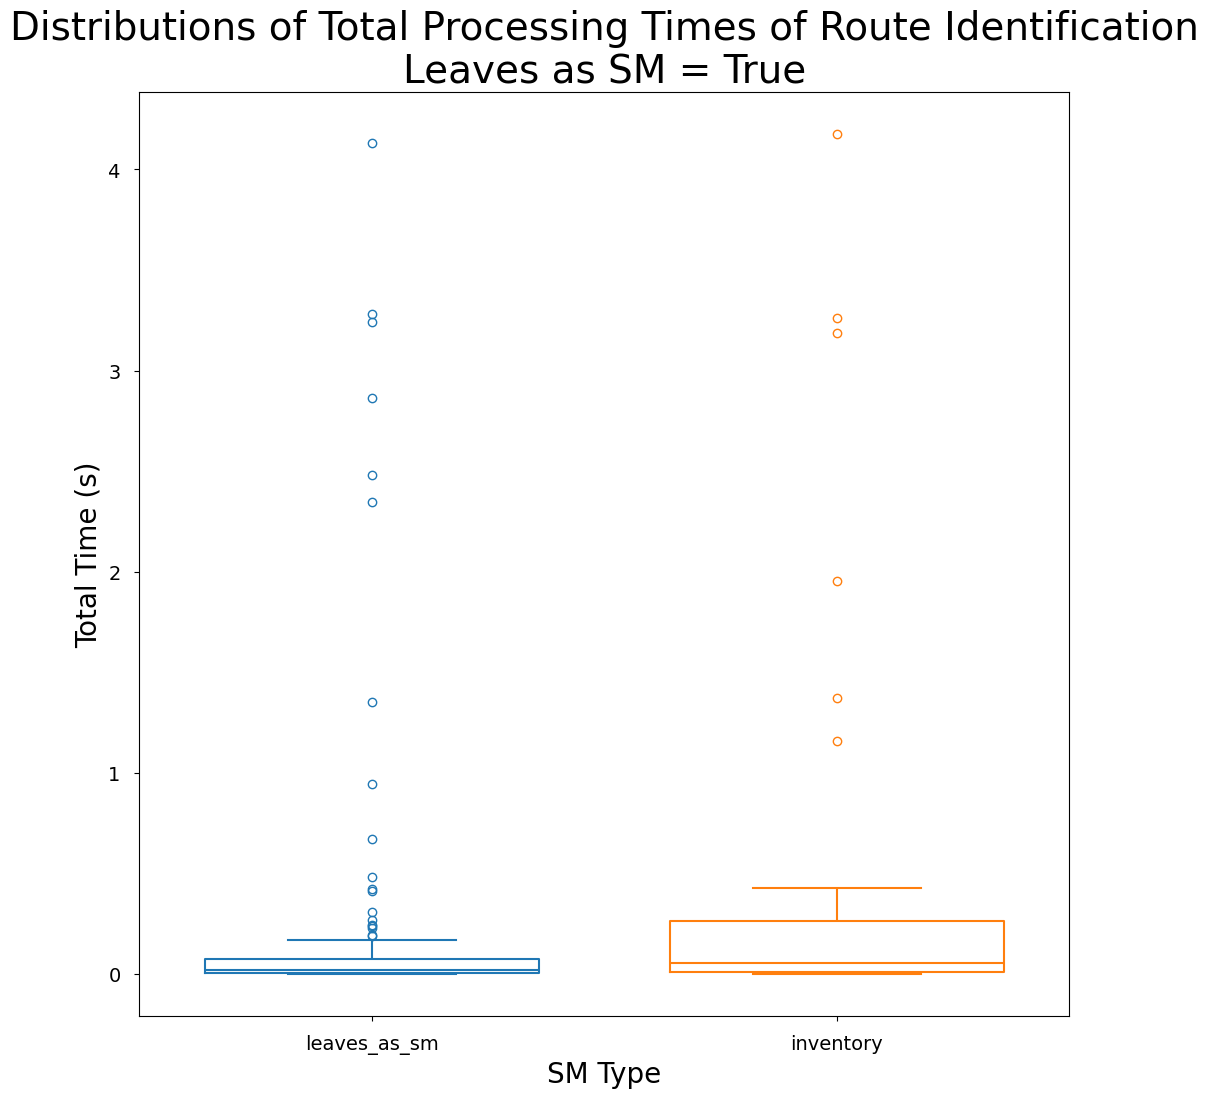

In [10]:

plt.figure(figsize=(12,12))

plt.title('Distributions of Total Processing Times of Route Identification\nLeaves as SM = True', fontsize = 28)


ax = sns.boxplot(data = df_time_evidence, x = 'sm_type', y = 'total_time_sec', hue = 'sm_type', fill=False, gap = 0.1)


ax.set_xlabel("SM Type", fontsize=20)
ax.set_ylabel("Total Time (s)", fontsize=20)
ax.tick_params(axis='both', labelsize=14, pad = 10)

#plt.savefig(FNAME_OUT_PLOT_SIM_DIST_LAN)
plt.show()          
plt.close()

<Figure size 1200x1200 with 0 Axes>

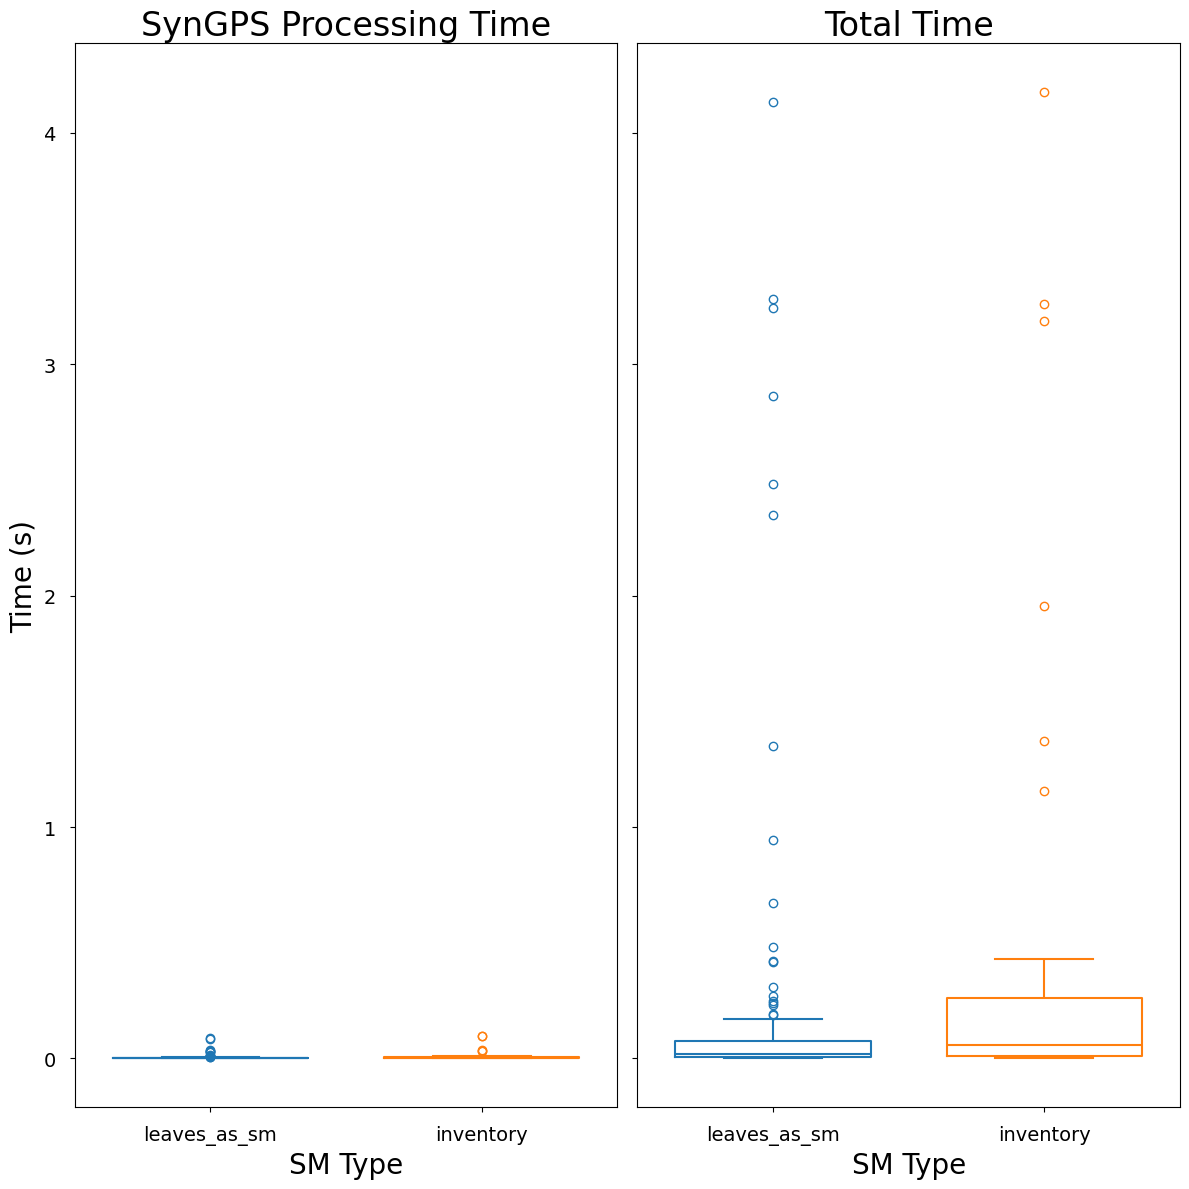

[Done.]


In [11]:
plt.figure(figsize=(12,12))

fig, axes = plt.subplots(1, 2, figsize = (12,12), sharex = True, sharey = True)



ax = sns.boxplot(data = df_time_evidence, x = 'sm_type', y = 'route_find_time_sec', hue = 'sm_type', fill=False, gap = 0.1, ax = axes[0])


axes[0].set_title('SynGPS Processing Time', fontsize = 24)
axes[0].set_xlabel("SM Type", fontsize = 20)
axes[0].set_ylabel("Time (s)", fontsize = 20)
axes[0].tick_params(axis = 'both', labelsize = 14, pad = 10)

ax = sns.boxplot(data = df_time_evidence, x = 'sm_type', y = 'total_time_sec', hue = 'sm_type', fill=False, gap = 0.1, ax = axes[1])


axes[1].set_title('Total Time', fontsize = 24)
axes[1].set_xlabel("SM Type", fontsize = 20)
axes[1].set_ylabel("Time (s)", fontsize = 20)
axes[1].tick_params(axis = 'both', labelsize = 14, pad = 10)

plt.tight_layout()

plt.savefig(FNAME_OUT_PLOT_TIME_DIST)


plt.show()

plt.close()

print ('[Done.]')

In [12]:
# References
#
# Ref: https://seaborn.pydata.org/generated/seaborn.boxplot.html
# Ref: https://www.pythonfordatascience.org/parametric-assumptions-python/
# Ref: https://www.statisticshowto.com/unequal-sample-sizes/
# Ref: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html
# Ref: https://stackoverflow.com/questions/65896805/how-to-save-a-seaborn-plot-as-svg-or-png
# Ref: https://stackoverflow.com/questions/65896805/how-to-save-a-seaborn-plot-as-svg-or-png
# Ref: https://medium.com/tomtalkspython/saving-and-exporting-seaborn-visualizations-b86ffb7c3d6d
# Ref: https://www.geeksforgeeks.org/python/how-to-change-the-size-of-axis-labels-in-matplotlib/
# Ref: https://www.geeksforgeeks.org/data-visualization/how-to-change-label-font-sizes-in-seaborn/
# Ref: https://stackoverflow.com/questions/66226320/how-do-you-add-padding-between-the-x-axis-tick-marks-not-tick-labels-and-the-x
# Ref: https://www.geeksforgeeks.org/python/how-to-create-subplots-in-seaborn/







